# Compare RL (MC-PILCO) vs PID baseline

Loads a trained MC-PILCO policy and evaluates it against the PID baseline on a block of held-out seeds. Reports paired yield statistics (mean delta, 95% CI, t-test, Wilcoxon, win-rate) and plots seed-averaged trajectories.

Notebook version of `03_compare_rl_vs_pid.py`.

## Imports & path setup

In [5]:
import os as _os, sys as _sys

# repo root = parent of the experiments/ dir
_ROOT = _os.path.dirname(_os.path.abspath("03_compare_rl_vs_pid.ipynb"))
if _os.path.basename(_ROOT) == "experiments":
    _ROOT = _os.path.dirname(_ROOT)
_sys.path.insert(0, _ROOT)
_sys.path.insert(0, _os.path.dirname(_ROOT))

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from mcpilco.config_single_phase import get_config
from mcpilco.pensim_wrapper import PenSimWrapper, PenSimMCPILCO, CONTROL_H, T_SAMPLING, PAA_BAND
from experiments.eval_utils import yield_kg, constraint_diagnostics

%matplotlib inline

## Parameters

(Replaces the argparse CLI arguments — edit these directly.)

In [6]:
# which trained policy (seed) to load
seed = 0

num_trials = 10     # trial count of that run (last trial is loaded)
n_seeds = 20        # number of held-out eval seeds
eval_base = 700000  # held-out seed block start
log_dir = "/Users/rokaspranevicius/Documents/Aca/UniversityOfEdinburgh/MSc/pensimpy_mcpilco/pensim_mcpilco/results/single_phase/cluster/seed0"      # folder with log.pkl (default: config log_path)
out_dir = "/Users/rokaspranevicius/Documents/Aca/UniversityOfEdinburgh/MSc/pensimpy_mcpilco/pensim_mcpilco/results/rl_vs_pid"       # output dir (default: results/rl_vs_pid)

## Config, output dir & held-out seed guard

Eval seeds must be disjoint from the policy's training window `[seed*1000, seed*1000 + 4 + num_trials]` (5 explorations + `num_trials` trials).

In [7]:
cfg = get_config(seed=seed, num_trials=num_trials)
folder = str(log_dir or cfg["mc_pilco_init"]["log_path"]).rstrip("/") + "/"
out = Path(out_dir or _os.path.join(_ROOT, "results/rl_vs_pid"))
out.mkdir(parents=True, exist_ok=True)

train_lo, train_hi = seed * 1000, seed * 1000 + 4 + num_trials
eval_seeds = [eval_base + i for i in range(n_seeds)]
assert all(not (train_lo <= h <= train_hi) for h in eval_seeds), \
    f"eval seeds overlap training window [{train_lo},{train_hi}]"

print(f"training window: [{train_lo}, {train_hi}]")
print(f"eval seeds: {eval_seeds[0]}..{eval_seeds[-1]} ({n_seeds} seeds)")
print(f"output dir: {out}")

training window: [0, 14]
eval seeds: 700000..700019 (20 seeds)
output dir: /Users/rokaspranevicius/Documents/Aca/UniversityOfEdinburgh/MSc/pensimpy_mcpilco/pensim_mcpilco/results/rl_vs_pid


## Load trained policy

In [8]:
def run_arm(wrapper, seed, policy=None, pid_baseline=False):
    """Run one batch on `seed` and return its monitor dict."""
    wrapper.rollout(None, policy, CONTROL_H, T_SAMPLING, 0, seed=seed, pid_baseline=pid_baseline)
    return wrapper.monitor[-1]


wrapper = PenSimWrapper()
agent = PenSimMCPILCO(pensim_wrapper=wrapper, **cfg["mc_pilco_init"])
agent.load_policy_from_log(num_trial=num_trials, folder=folder)
np_policy = agent.control_policy.get_np_policy()
print("policy loaded")



Get the system...


Get the learning object...
GP APPROXIMATION SELECTED
APPROXIMATION MODE:  SOD
APPROXIMATION OPTIONS:  {'SOD_threshold_mode': 'relative', 'SOD_threshold': 0.3, 'flg_SOD_permutation': False}


Get the exploration policy...


Get the control policy...


Get the cost function...

Loading policy from: /Users/rokaspranevicius/Documents/Aca/UniversityOfEdinburgh/MSc/pensimpy_mcpilco/pensim_mcpilco/results/single_phase/cluster/seed0/log.pkl
policy loaded


## Evaluate RL vs PID on held-out seeds

In [9]:
rows, mons_rl, mons_pid = [], [], []
for h in eval_seeds:
    m_rl = run_arm(wrapper, h, policy=np_policy, pid_baseline=False)
    m_pid = run_arm(wrapper, h, policy=None, pid_baseline=True)
    mons_rl.append(m_rl)
    mons_pid.append(m_pid)
    y_rl, y_pid = yield_kg(m_rl), yield_kg(m_pid)
    row = {"seed": h, "yield_rl": y_rl, "yield_pid": y_pid, "delta": y_rl - y_pid}
    row.update({f"rl_{k}": v for k, v in constraint_diagnostics(m_rl).items()})
    row.update({f"pid_{k}": v for k, v in constraint_diagnostics(m_pid).items()})
    rows.append(row)
    print(f"seed {h}: yield_rl={y_rl:8.2f}  yield_pid={y_pid:8.2f}  delta={y_rl - y_pid:+8.2f}")

df = pd.DataFrame(rows)
# df.to_csv(out / "paired_metrics.csv", index=False)
df

seed 700000: yield_rl= 3467.32  yield_pid= 3467.33  delta=   -0.01
seed 700001: yield_rl= 3573.81  yield_pid= 3573.90  delta=   -0.09
seed 700002: yield_rl= 3697.02  yield_pid= 3696.62  delta=   +0.40
seed 700003: yield_rl= 3526.49  yield_pid= 3526.59  delta=   -0.10
seed 700004: yield_rl= 3214.95  yield_pid= 3214.51  delta=   +0.45
seed 700005: yield_rl= 4122.06  yield_pid= 4121.99  delta=   +0.07
seed 700006: yield_rl= 3985.80  yield_pid= 3985.76  delta=   +0.04
seed 700007: yield_rl= 3355.08  yield_pid= 3355.20  delta=   -0.11
seed 700008: yield_rl= 3303.88  yield_pid= 3303.83  delta=   +0.05
seed 700009: yield_rl= 3388.90  yield_pid= 3388.79  delta=   +0.11
seed 700010: yield_rl= 3441.60  yield_pid= 3441.45  delta=   +0.15
seed 700011: yield_rl= 3637.84  yield_pid= 3637.88  delta=   -0.04
seed 700012: yield_rl= 3733.46  yield_pid= 3733.48  delta=   -0.02
seed 700013: yield_rl= 3359.87  yield_pid= 3359.78  delta=   +0.09
seed 700014: yield_rl= 3804.18  yield_pid= 3804.29  delta=   -

,seed,yield_rl,yield_pid,delta,rl_final_P,rl_max_Wt,rl_wt_overflow,rl_paa_frac_out_of_band,rl_max_viscosity,rl_visc_exceed,pid_final_P,pid_max_Wt,pid_wt_overflow,pid_paa_frac_out_of_band,pid_max_viscosity,pid_visc_exceed
0,700000,3467.315828,3467.328902,-0.013075,27.429400,101046.511089,False,0.0,81.013721,False,27.424360,101050.051771,False,0.0,81.007048,False
1,700001,3573.805374,3573.899211,-0.093837,27.760588,106069.093090,False,0.0,71.810564,False,27.762091,106086.753636,False,0.0,71.801539,False
2,700002,3697.022913,3696.618223,0.404689,30.027320,98591.610051,False,0.0,89.920413,False,30.024651,98603.657446,False,0.0,89.916614,False
3,700003,3526.488764,3526.588600,-0.099836,27.110879,105610.683063,False,0.0,75.314621,False,27.108314,105621.700489,False,0.0,75.306299,False
4,700004,3214.952170,3214.506607,0.445563,24.892272,101726.072633,False,0.0,79.898239,False,24.884472,101732.672304,False,0.0,79.894066,False
5,700005,4122.059906,4121.994871,0.065035,33.185877,100753.330160,False,0.0,83.839616,False,33.186527,100767.755911,False,0.0,83.831039,False
6,700006,3985.795118,3985.758209,0.036910,31.143671,99808.726407,False,0.0,82.302789,False,31.144028,99823.135307,False,0.0,82.294348,False
7,700007,3355.084374,3355.199307,-0.114933,25.990096,101032.011670,False,0.0,80.198558,False,25.989071,101047.041686,False,0.0,80.189679,False
8,700008,3303.876246,3303.827995,0.048251,24.987488,104442.327529,False,0.0,74.092032,False,24.982934,104449.346185,False,0.0,74.085064,False
9,700009,3388.897163,3388.790303,0.106860,25.595515,105039.104326,False,0.0,75.553581,False,25.589508,105056.859282,False,0.0,75.543685,False


## Paired statistics

In [10]:
delta = df["delta"].values
n = len(delta)
mean_d = float(delta.mean())
se = float(delta.std(ddof=1) / np.sqrt(n)) if n > 1 else float("nan")
ci = 1.96 * se
t_p = float(stats.ttest_rel(df["yield_rl"], df["yield_pid"]).pvalue) if n > 1 else float("nan")
try:
    w_p = float(stats.wilcoxon(df["yield_rl"], df["yield_pid"]).pvalue)
except ValueError:
    w_p = float("nan")  # e.g. all-zero differences

summary = pd.DataFrame([{
    "n_seeds": n,
    "mean_yield_rl": float(df["yield_rl"].mean()),
    "mean_yield_pid": float(df["yield_pid"].mean()),
    "mean_delta": mean_d,
    "delta_ci95_lo": mean_d - ci,
    "delta_ci95_hi": mean_d + ci,
    "ttest_p": t_p,
    "wilcoxon_p": w_p,
    "winrate_rl_gt_pid": float((delta > 0).mean()),
}])
# summary.to_csv(out / "summary.csv", index=False)
print("=== SUMMARY ===")
print(summary.T.to_string(header=False))

=== SUMMARY ===
n_seeds              20.000000
mean_yield_rl      3514.347530
mean_yield_pid     3514.300776
mean_delta            0.046754
delta_ci95_lo        -0.026333
delta_ci95_hi         0.119842
ttest_p               0.225117
wilcoxon_p            0.329983
winrate_rl_gt_pid     0.600000


## Overview plots: paired yield, per-seed delta, seed-averaged penicillin

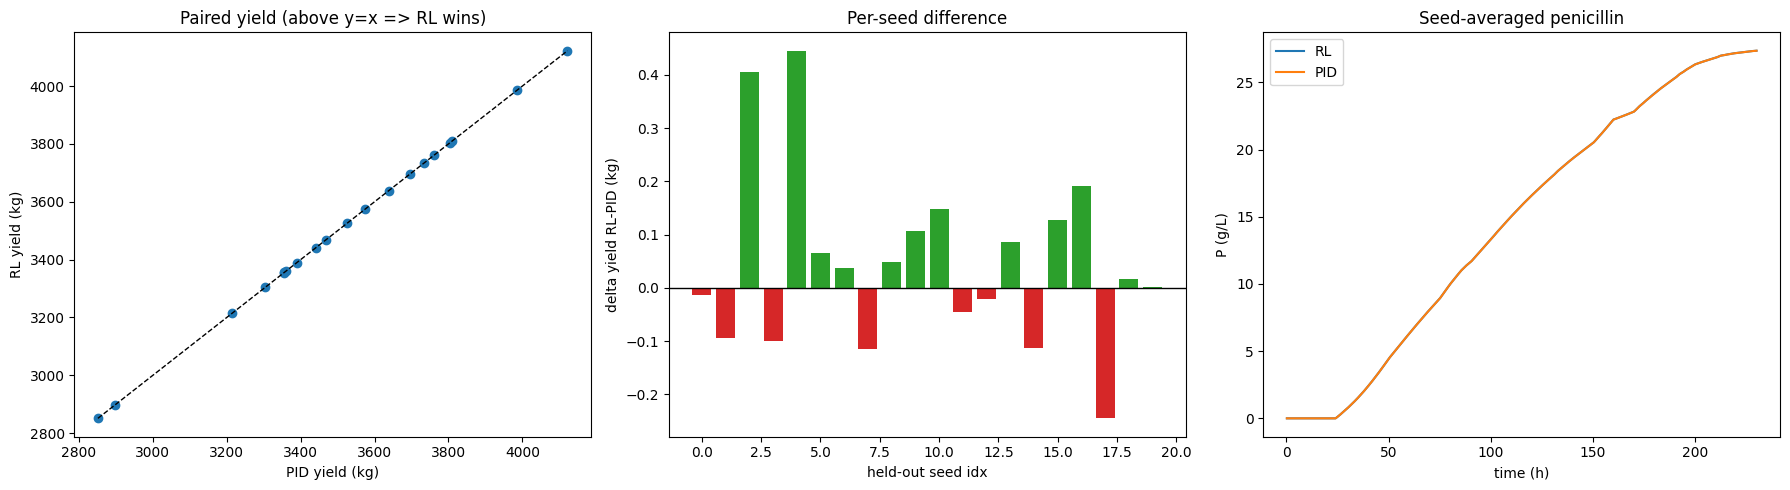

In [11]:
t = np.asarray(mons_rl[0]["t"])
avg = lambda mons, key: np.mean([m[key] for m in mons], axis=0)

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
lo = float(min(df["yield_pid"].min(), df["yield_rl"].min()))
hi = float(max(df["yield_pid"].max(), df["yield_rl"].max()))
ax[0].plot([lo, hi], [lo, hi], "k--", lw=1)
ax[0].scatter(df["yield_pid"], df["yield_rl"], c="C0")
ax[0].set_xlabel("PID yield (kg)")
ax[0].set_ylabel("RL yield (kg)")
ax[0].set_title("Paired yield (above y=x => RL wins)")

ax[1].bar(np.arange(len(df)), df["delta"].values,
          color=["C2" if d > 0 else "C3" for d in df["delta"]])
ax[1].axhline(0, color="k", lw=1)
ax[1].set_xlabel("held-out seed idx")
ax[1].set_ylabel("delta yield RL-PID (kg)")
ax[1].set_title("Per-seed difference")

ax[2].plot(t, avg(mons_rl, "P"), label="RL", color="C0")
ax[2].plot(t, avg(mons_pid, "P"), label="PID", color="C1")
ax[2].set_xlabel("time (h)")
ax[2].set_ylabel("P (g/L)")
ax[2].set_title("Seed-averaged penicillin")
ax[2].legend()
fig.tight_layout()
# fig.savefig(out / "rl_vs_pid_overview.png", dpi=120)
plt.show()

## Control plots: seed-averaged Fpaa & PAA

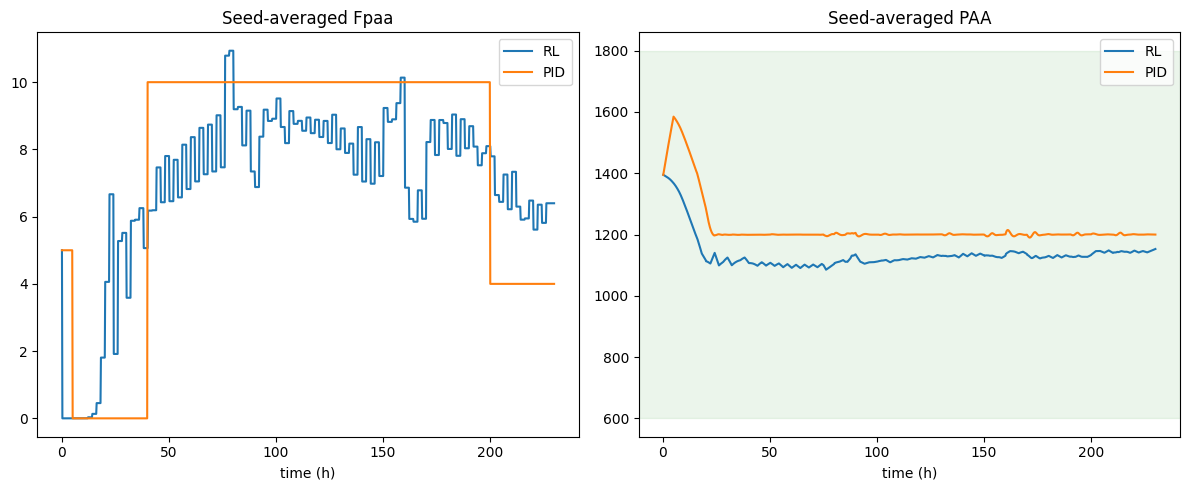

Saved results to /Users/rokaspranevicius/Documents/Aca/UniversityOfEdinburgh/MSc/pensimpy_mcpilco/pensim_mcpilco/results/rl_vs_pid


In [12]:
fig2, ax2 = plt.subplots(1, 2, figsize=(12, 5))
for key, axx in [("Fpaa", ax2[0]), ("PAA", ax2[1])]:
    axx.plot(t, avg(mons_rl, key), label="RL", color="C0")
    axx.plot(t, avg(mons_pid, key), label="PID", color="C1")
    axx.set_xlabel("time (h)")
    axx.set_title(f"Seed-averaged {key}")
    axx.legend()
ax2[1].axhspan(PAA_BAND[0], PAA_BAND[1], color="green", alpha=0.08)  # PAA target band
fig2.tight_layout()
# fig2.savefig(out / "rl_vs_pid_control.png", dpi=120)
plt.show()

print(f"Saved results to {out}")